

# СӨЖ
# Сверткалық Нейрондық Желілер (CNN) және CIFAR-10

**Мақсаты:** Сверткалық нейрондық желілердің (CNN) жұмыс істеу принципін түсіну және CIFAR-10 деректер жиынтығындағы түрлі-түсті суреттерді классификациялау үшін модель құру.

**Сіздің тапсырмаңыз:** Төмендегі код ұяшықтарында `# TODO` деп белгіленген жерлерді дұрыс кодпен немесе мәнмен толтыру.




### 1. Қысқаша теория

Сверткалық нейрондық желілер (CNN) – бұл суреттерді өңдеуге арналған ең тиімді архитектура. Ол негізгі үш бөліктен тұрады:

1. **Convolutional Layer (Сверткалық қабат):** Суреттің үстінен кішкентай "сүзгілер" (filters) жүргізу арқылы маңызды белгілерді (сызықтар, бұрыштар, фактуралар) бөліп алады.
* *Функция:* `layers.Conv2D`


2. **Pooling Layer (Пулинг қабаты):** Суреттің өлшемін кішірейтеді, есептеуді жеңілдетеді және маңызды ақпаратты қалдырады. Ең көп тарағаны – Max Pooling (аймақтағы ең үлкен мәнді алу).
* *Функция:* `layers.MaxPooling2D`


3. **Fully Connected Layer (Толық байланысқан қабат):** Соңында табылған белгілерді біріктіріп, суреттің қай класқа жататынын анықтайды.
* *Функция:* `layers.Dense`



Алдымен қажетті кітапханаларды қосайық.

In [2]:
import tensorflow as tf
from tensorflow.keras import datasets, layers, models
import matplotlib.pyplot as plt
import numpy as np

# Нұсқаны тексеру
print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0



### 2. Деректерді жүктеу (CIFAR-10)

Біз **CIFAR-10** датасетін қолданамыз. Онда 10 түрлі класқа жататын 60,000 түрлі-түсті сурет (32x32 пиксель) бар.
Кластар: *'ұшақ', 'автокөлік', 'құс', 'мысық', 'бұғы', 'ит', 'бақа', 'жылқы', 'кеме', 'жүк көлігі'.*


170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 21s 0us/step


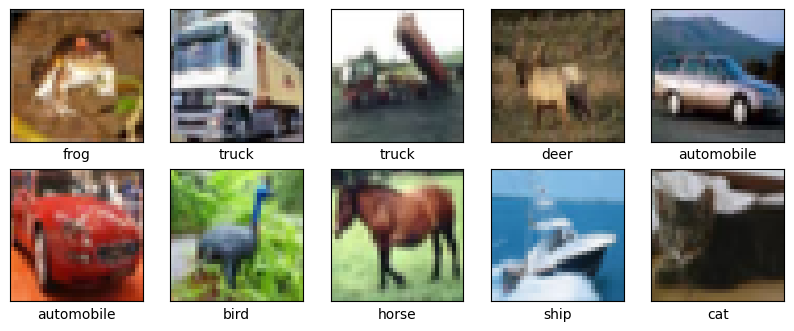

In [3]:
# Деректерді жүктеу
(train_images, train_labels), (test_images, test_labels) = datasets.cifar10.load_data()

# Пиксель мәндерін 0 мен 1 аралығына келтіру (Нормализация)
# TODO: Студент сурет пиксельдерін нормализациялауы керек (255.0-ге бөлу)
train_images = train_images / 255.0  # Осы жерге бөлу мәнін жазыңыз
test_images  = test_images  / 255.0  # Осы жерге бөлу мәнін жазыңыз

# Класс атаулары
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer',
               'dog', 'frog', 'horse', 'ship', 'truck']

# Деректердің дұрыс жүктелгенін тексеру (алғашқы 10 суретті шығару)
plt.figure(figsize=(10,10))
for i in range(10):
    plt.subplot(5, 5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    # CIFAR labels массивтер болып табылады, сондықтан қосымша индекс керек
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()


### 3. CNN Архитектурасын құру (Негізгі тапсырма)

Бұл бөлімде сіз нейрондық желінің "қаңқасын" жинайсыз.
Сызба мынадай болуы керек:

1. **Conv2D:** 32 фильтр, (3, 3) өлшем, 'relu' активациясы, кіріс өлшемі (32, 32, 3).
2. **MaxPooling2D:** (2, 2) өлшемі.
3. **Conv2D:** 64 фильтр, (3, 3) өлшем, 'relu' активациясы.
4. **MaxPooling2D:** (2, 2) өлшемі.
5. **Conv2D:** 64 фильтр, (3, 3) өлшем, 'relu' активациясы.
6. **Flatten:** Векторға айналдыру.
7. **Dense:** 64 нейрон, 'relu' активациясы.
8. **Dense (Шығыс):** 10 нейрон (кластар саны).

**Тапсырма:** Төмендегі кодта қалдырылған `# TODO` орындарын толтырыңыз.


In [4]:
model = models.Sequential()

# --- Feature Extraction (Белгілерді алу) бөлігі ---

# 1-қабат: Конволюция
# TODO: filters=32, kernel_size=(3,3), activation='relu', input_shape=(32, 32, 3) параметрлерін қосыңыз
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 3)))

# 2-қабат: Пулинг
# TODO: pool_size=(2, 2) параметрін қосыңыз
model.add(layers.MaxPooling2D((2, 2)))

# 3-қабат: Конволюция (фильтр санын 64-ке көбейтіңіз)
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

# 4-қабат: Пулинг
model.add(layers.MaxPooling2D((2, 2)))

# 5-қабат: Конволюция (64 фильтр)
model.add(layers.Conv2D(64, (3, 3), activation='relu'))

# Classification (Жіктеу) бөлігі

# 6-қабат: Flatten (Жалпақтау – 3D тензорды 1D векторға айналдыру)
model.add(layers.Flatten())

# 7-қабат: Dense (Толық байланысқан қабат)
# TODO: 64 нейрон және 'relu' активациясын қолданыңыз
model.add(layers.Dense(64, activation='relu'))

# 8-қабат: Шығыс қабаты
# TODO: CIFAR-10 датасетінде қанша класс бар? Соған сәйкес нейрон санын жазыңыз.
model.add(layers.Dense(10))

# Модель құрылымын тексеру
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 4, 4, 64)       │        36,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │        65,600 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 122,570 (478.79 KB)

 Trainable params: 122,570 (478.79 KB)

 Non-trainable params: 0 (0.00 B)


### 4. Модельді компиляциялау және оқыту

Модель дайын, енді оны оқыту ережелерін бекітуіміз керек.

* **Optimizer:** `adam` (ең танымал оптимизатор).
* **Loss Function:** `SparseCategoricalCrossentropy` (кластар сандармен берілген кезде қолданылады).
* **Metrics:** `accuracy` (дәлдік).

**Тапсырма:** Компиляция және оқыту параметрлерін толтырыңыз.


In [5]:
# Модельді компиляциялау
# TODO: optimizer='adam' деп көрсетіңіз
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

# Модельді оқыту (Training)
# TODO: epochs=10 (оқыту циклінің саны) деп көрсетіңіз
# validation_data ретінде (test_images, test_labels) қолданыңыз
history = model.fit(train_images, train_labels,
                    epochs=10,
                    validation_data=(test_images, test_labels))

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 19s 9ms/step - accuracy: 0.4665 - loss: 1.4657 - val_accuracy: 0.5711 - val_loss: 1.1729
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 5ms/step - accuracy: 0.6120 - loss: 1.0954 - val_accuracy: 0.6326 - val_loss: 1.0577
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6646 - loss: 0.9532 - val_accuracy: 0.6704 - val_loss: 0.9455
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6950 - loss: 0.8629 - val_accuracy: 0.6899 - val_loss: 0.8909
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7168 - loss: 0.8033 - val_accuracy: 0.6754 - val_loss: 0.9403
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7408 - loss: 0.7413 - val_accuracy: 0.6880 - val_loss: 0.9099
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7544 - loss: 0.6959 - val_accuracy: 0.7173 - val_loss: 0.8347
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.7727 - loss: 0.6461 



### 5. Нәтижелерді бағалау

Модельдің оқу барысында қателіктер қалай азайғанын және дәлдік қалай өскенін график арқылы көрейік.


In [ ]:
plt.plot(history.history['accuracy'],     label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.ylim([0.5, 1])
plt.legend(loc='lower right')
plt.title('Модельдің дәлдік графигі')
plt.show()

# Тест жиынтығындағы соңғы дәлдікті есептеу
test_loss, test_acc = model.evaluate(test_images, test_labels, verbose=2)
print(f"\nМодельдің тесттері дәлдігі: {test_acc*100:.2f}%")


### 6. Модельді тексеру (Prediction)

Енді моделіміз нақты суретті қалай танитынын тексерейік. Біз тест жиынтығынан кездейсоқ бір суретті алып, модельге ұсынамыз.


In [ ]:
# Тест жиынтығынан 10-шы суретті алайық
n = 10

plt.imshow(test_images[n])
plt.title(f"Шын мәні: {class_names[test_labels[n][0]]}")
plt.show()

# Болжам жасау
# Суретті (32,32,3) пішінінен (1, 32, 32, 3) пішініне ауыстыру керек (batch өлшемі)
img_array = np.expand_dims(test_images[n], axis=0)

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

print(f"Бұл сурет {100 * np.max(score):.2f}% ықтималдықпен '{class_names[np.argmax(score)]}' деп танылды.")



### Қорытынды сұрақтар

Зертханалық жұмысты қорғау үшін келесі сұрақтарға жауап дайындаңыз:

1. Неліктен біз `Conv2D` қабатын қолданамыз, жай ғана `Dense` қабаттары жеткіліксіз бе?

Dense қабаттары суреттің барлық пикселін бір-бірімен байланыстырады — бұл өте көп параметр талап етеді және суреттің кеңістіктік құрылымын (жиектер, пішіндер, текстуралар) ескермейді. Мысалы, 32×32×3 сурет үшін Dense қабаты 3072 кіріс нейронын қажет етеді.Conv2D қабаты кішкентай фильтр (3×3) арқылы суреттің үстінен жүреді және:

Жергілікті белгілерді (сызықтар, бұрыштар, текстуралар) анықтайды
Параметрлер санын күрт азайтады
Суреттің кеңістіктік байланысын сақтайды
Бір фильтр суреттің кез келген жерінде бірдей белгіні таниды (translation invariance)
Сондықтан суреттерді өңдеуде Conv2D әлдеқайда тиімді.

2. `MaxPooling` қабаты суреттің өлшемін қалай өзгертеді және оның пайдасы неде?

MaxPooling2D((2,2)) қабаты әрбір 2×2 аймақтан ең үлкен мәнді алады, нәтижесінде сурет өлшемі 2 есе кішірейеді:
32×32 → 16×16 → 8×8
Пайдасы:

Есептеу жылдамдығы — параметрлер саны азаяды
Overfitting азаяды — артық ақпарат алынып тасталады
Негізгі белгілер сақталады — ең маңызды белгілер (максимум мәндер) қалады
Масштабқа төзімділік — сурет сәл өзгерсе де, модель дұрыс таниды

3. Егер `epochs` санын 10-нан 50-ге дейін көбейтсек, нәтиже қалай өзгеруі мүмкін? (Overfitting туралы ойланыңыз).

Epochs санын көбейтудің екі жағы бар:
Оң жағы (10→20 шамасында):

Модель деректерді жақсырақ үйренеді
Training және Validation дәлдігі бірге өседі
Жалпы нәтиже жақсарады

Теріс жағы — Overfitting (артық үйрену):
Егер epochs тым көп болса, модель тек жаттықтыру деректерін "жаттап алады" — жаңа суреттерді дұрыс тани алмайды:
Epoch 10:  Train accuracy: 75%,  Val accuracy: 72%   Жақсы
Epoch 30:  Train accuracy: 90%,  Val accuracy: 75%   Алшақтай бастады
Epoch 50:  Train accuracy: 99%,  Val accuracy: 68%   Overfitting!
Overfitting-тен қорғану жолдары:

Dropout қабатын қосу
BatchNormalization қолдану
EarlyStopping (validation loss өспесе, оқытуды тоқтату)
Data Augmentation (деректерді жасанды көбейту)

# Жалпы дәлдік 90+

In [ ]:
# Жалпы дәлдікті 90%+ жеткізу үшін Data Augmentation және BatchNormalization қолданамыз

from tensorflow.keras.layers import BatchNormalization, Dropout
from tensorflow.keras.preprocessing.image import ImageDataGenerator

# Деректерді күшейту (Data Augmentation)
datagen = ImageDataGenerator(
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    horizontal_flip=True
)
datagen.fit(train_images)

# Жақсартылған модель
model2 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    BatchNormalization(),
    layers.Conv2D(32, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    Dropout(0.2),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    Dropout(0.3),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    Dropout(0.4),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    BatchNormalization(),
    Dropout(0.5),
    layers.Dense(10)
])

model2.compile(optimizer='adam',
               loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
               metrics=['accuracy'])

history2 = model2.fit(datagen.flow(train_images, train_labels, batch_size=64),
                      epochs=50,
                      validation_data=(test_images, test_labels))

test_loss2, test_acc2 = model2.evaluate(test_images, test_labels, verbose=2)
print(f"\nЖақсартылған модельдің дәлдігі: {test_acc2*100:.2f}%")